# Run FLUX.1-dev with Authentication on Modal

This notebook deploys the FLUX.1-dev image generation model and queries its secure web endpoint with proxy authentication.

### Step 1: Deploy the Model

In [ ]:
!uv run modal deploy ../llm-hosting/flux-dev

### Step 2: Load Credentials and Setup Endpoint

In [1]:
import os
import requests
import io
from PIL import Image

def load_dotenv():
    for path in [".env", "../.env", "../../.env"]:
        if os.path.exists(path):
            with open(path) as f:
                for line in f:
                    line = line.strip()
                    if line and not line.startswith("#") and "=" in line:
                        k, v = line.split("=", 1)
                        v = v.strip().strip("'\"")
                        os.environ.setdefault(k.strip(), v)
            break

load_dotenv()
MODAL_KEY = os.environ.get("MODAL_KEY")
MODAL_SECRET = os.environ.get("MODAL_SECRET")

if not MODAL_KEY or not MODAL_SECRET:
    print("WARNING: Credentials not loaded!")
else:
    print("Credentials loaded successfully!")

username = "sshibinthomass"
ENDPOINT_URL = f"https://{username}--flux-dev-2-fluxmodel-generate-api.modal.run"
print(f"Target Endpoint URL: {ENDPOINT_URL}")

Credentials loaded successfully!
Target Endpoint URL: https://sshibinthomass--flux-dev-2-fluxmodel-generate-api.modal.run


### Step 3: Run Authenticated Inference

Requesting image for prompt: 'A beautiful watercolor painting of a cabin in the snowy woods at dusk.'...


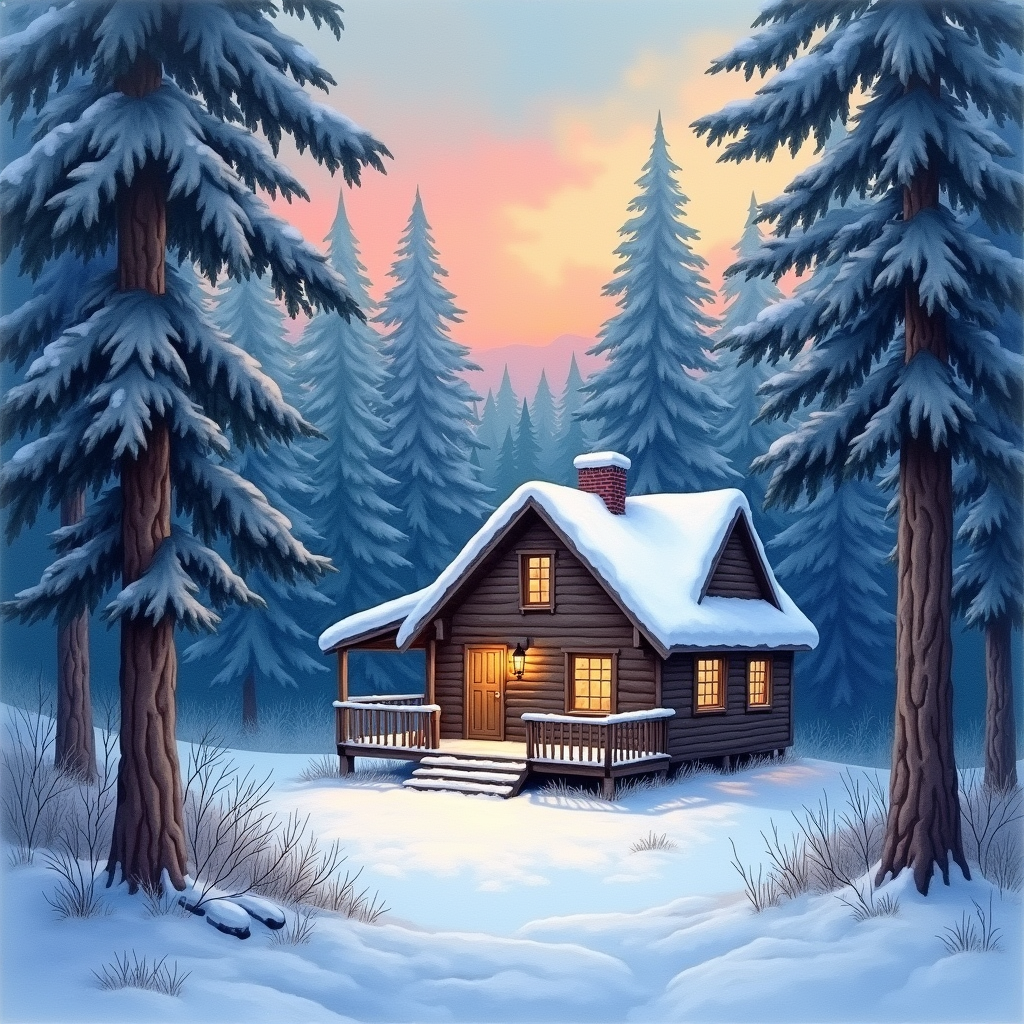

In [2]:
def test_inference(prompt: str, num_inference_steps: int = 28, guidance_scale: float = 3.5):
    headers = {
        "Content-Type": "application/json",
        "Modal-Key": MODAL_KEY,
        "Modal-Secret": MODAL_SECRET,
    }
    payload = {
        "prompt": prompt,
        "num_inference_steps": num_inference_steps,
        "guidance_scale": guidance_scale
    }
    
    print(f"Requesting image for prompt: '{prompt}'...")
    response = requests.post(ENDPOINT_URL, headers=headers, json=payload)
    if response.status_code == 200:
        return response.content
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None

prompt = "A beautiful watercolor painting of a cabin in the snowy woods at dusk."
img_bytes = test_inference(prompt)

if img_bytes:
    image = Image.open(io.BytesIO(img_bytes))
    display(image)

### Step 4: Verify Security (Unauthorized Calls)

In [ ]:
print("--- Test: Querying WITHOUT credentials ---")
response = requests.post(ENDPOINT_URL, json={"prompt": "Test"})
print(f"Status: {response.status_code} (Expected: 401)")
print(f"Message: {response.text}")